In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%config InlineBackend.figure_format = 'retina'

import random
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier

from abstractgraph_graphicalizer.chem import draw_molecules as display_graphs

from abstractgraph.operators import *
from abstractgraph.hashing import hash_graph
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator
from abstractgraph_generative.conditional_attributed import AttributedConditionalAutoregressiveGenerator
from abstractgraph_generative.conditional_batch import  ConditionalAutoregressiveGraphsGenerator
from abstractgraph_generative.edge_generator import (
    EdgeGenerator,
    edge_neighbors,
    make_edge_regression_dataset,
    remove_edges,
)


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


In [3]:
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)

nbits = 19
feasibility_kwargs = dict(
    nbits=nbits,
    parallel=True,
    backend='loky',
    n_jobs=-1,
)

feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=path(number_of_edges=2),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(combination(number_of_elements=(2, 3), distance=0), cycle(), unlabel()),
        **feasibility_kwargs,
    ),
]

feasibility_estimator = FeasibilityEstimator(feasibility_estimators)

size: 528
max_num_nodes: 17
dataset size: 10


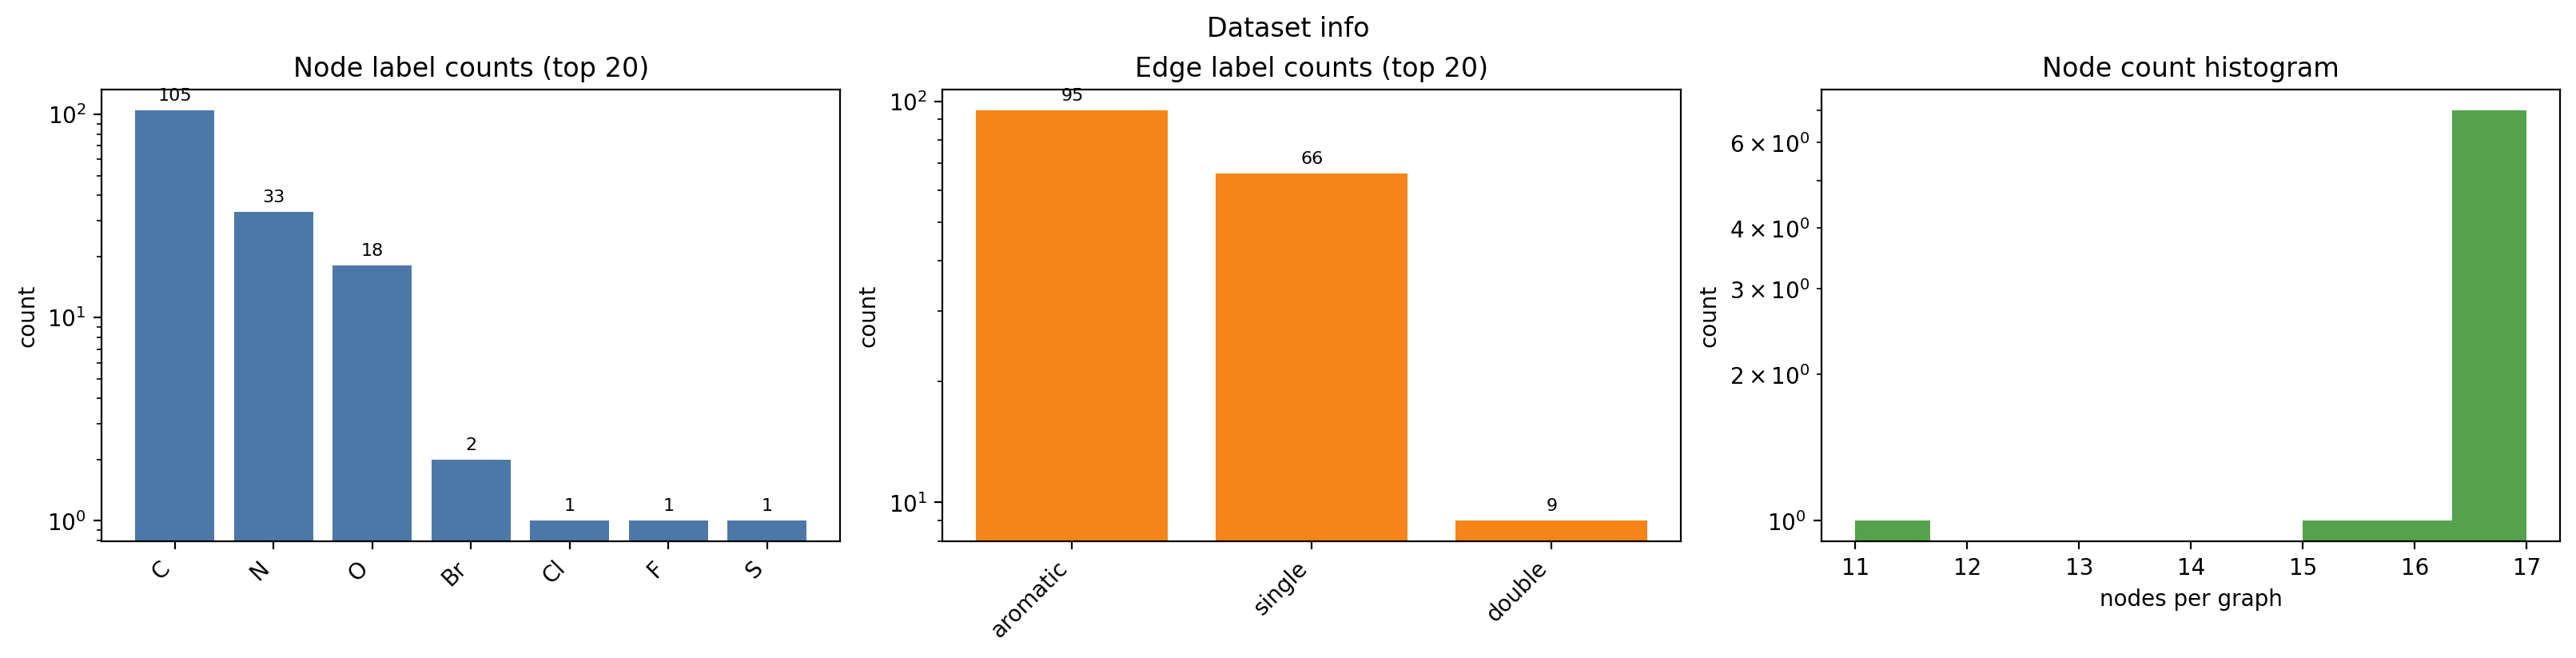

In [4]:
from abstractgraph_graphicalizer.chem import PubChemLoader

loader = PubChemLoader(on_error="skip")

assay_ids = ['2631','624249','651741','588350','463230','492952','743219','492992','463213']
assay_id = assay_ids[1]
assay_id = '624249' #bundled-safe assay example
size = 2000
max_num_nodes = 17
use_equalized = True


limit_active = int(size // 2) if use_equalized else int(size)
limit_inactive = int(size // 2) if use_equalized else int(size)
graphs, targets = loader.load(
    assay_id,
    limit_active=limit_active,
    limit_inactive=limit_inactive,
)
targets = np.array(targets)
print(f"size: {len(graphs)}")

keep = [i for i, graph in enumerate(graphs) if graph.number_of_nodes() <= max_num_nodes]
graphs = [graphs[i] for i in keep]
targets = targets[keep]

print(f"max_num_nodes: {max_num_nodes}")

from abstractgraph.utils import plot_graph_label_counts
_ = plot_graph_label_counts(graphs, top=20, title='Dataset info', log_scale=True)

# Keep downstream notebook cells unchanged
all_graphs = graphs
all_targets = targets
print('dataset size:', len(all_graphs))


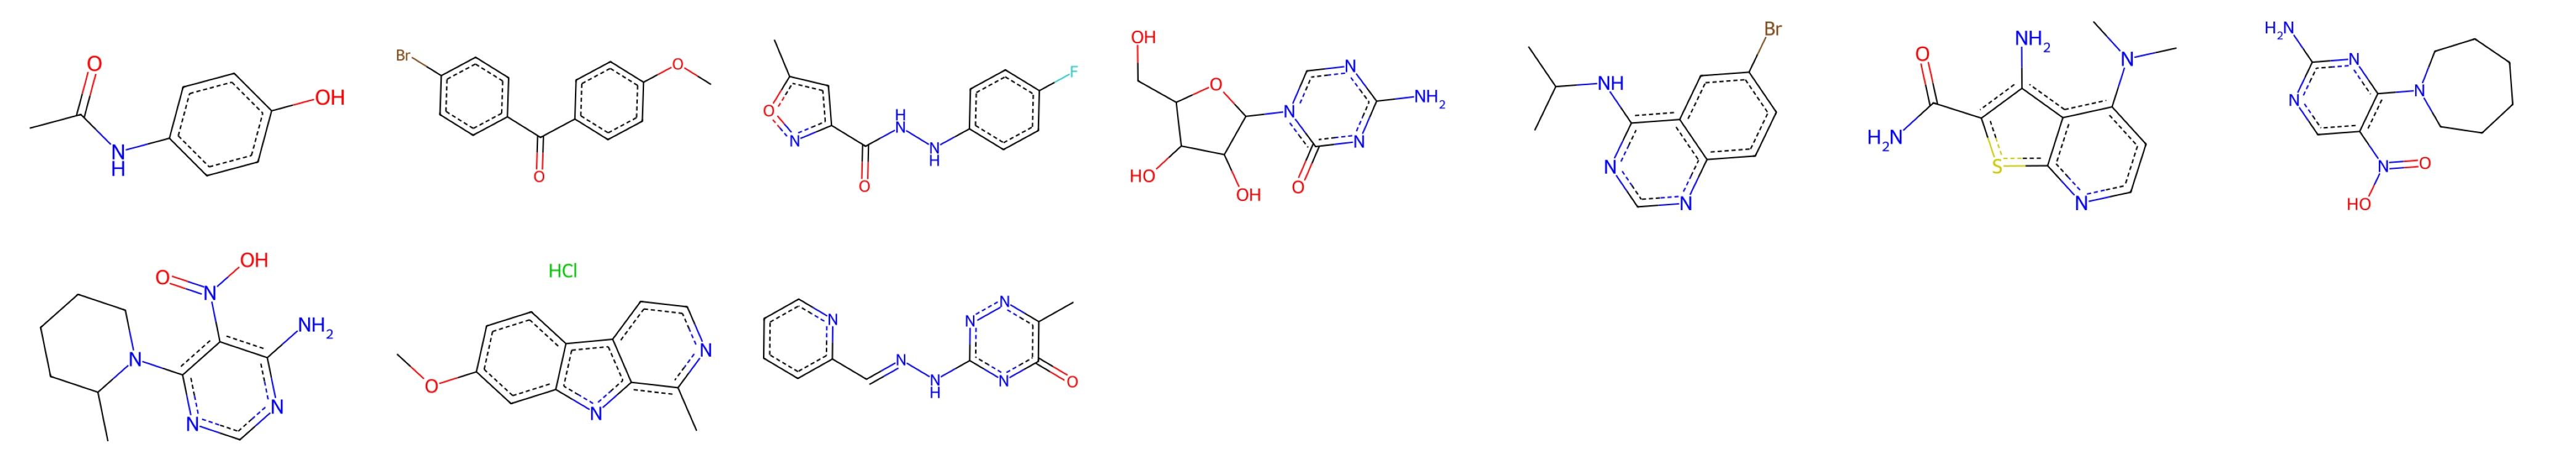

In [5]:
_ = display_graphs(graphs[:7*2], n_graphs_per_line=7)

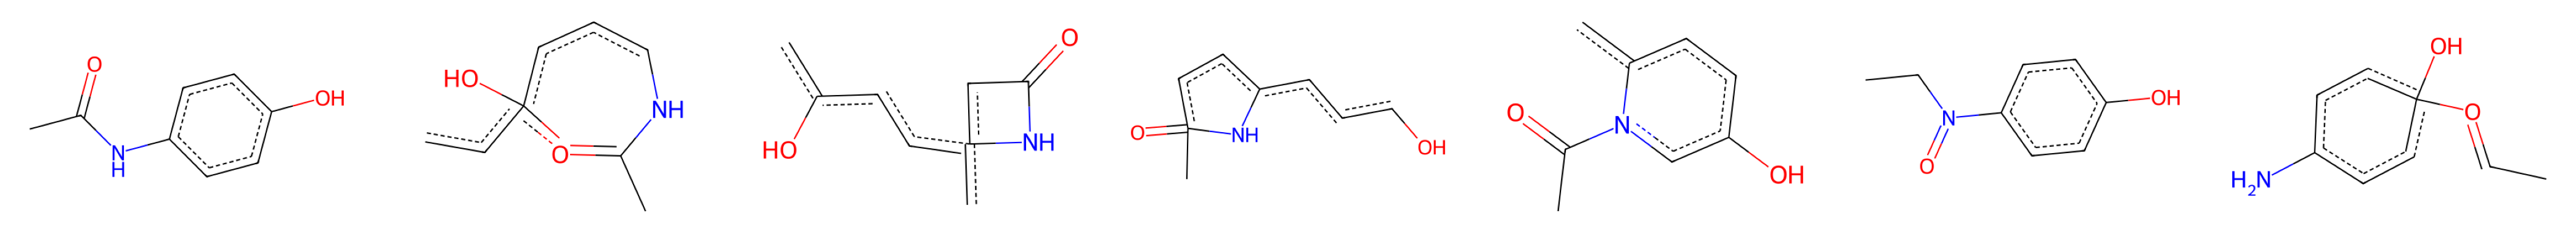

In [6]:
graph= graphs[0]
perturbed_graphs = edge_neighbors(graph, n_samples=6)
_ = display_graphs([graph]+perturbed_graphs, n_graphs_per_line=7)

In [7]:

n_negative_per_positive = 3
positives, negatives, dataset = make_edge_regression_dataset(
    graph,
    n_negative_per_positive=n_negative_per_positive,
    seed=0,
)

print('n_positives =', len(positives))
print('n_negatives =', len(negatives))
print('dataset_size =', len(dataset))
print('n_terminal_positives =', sum(G.number_of_edges() == 0 for G in positives))

n_positives = 11
n_negatives = 30
dataset_size = 41
n_terminal_positives = 1


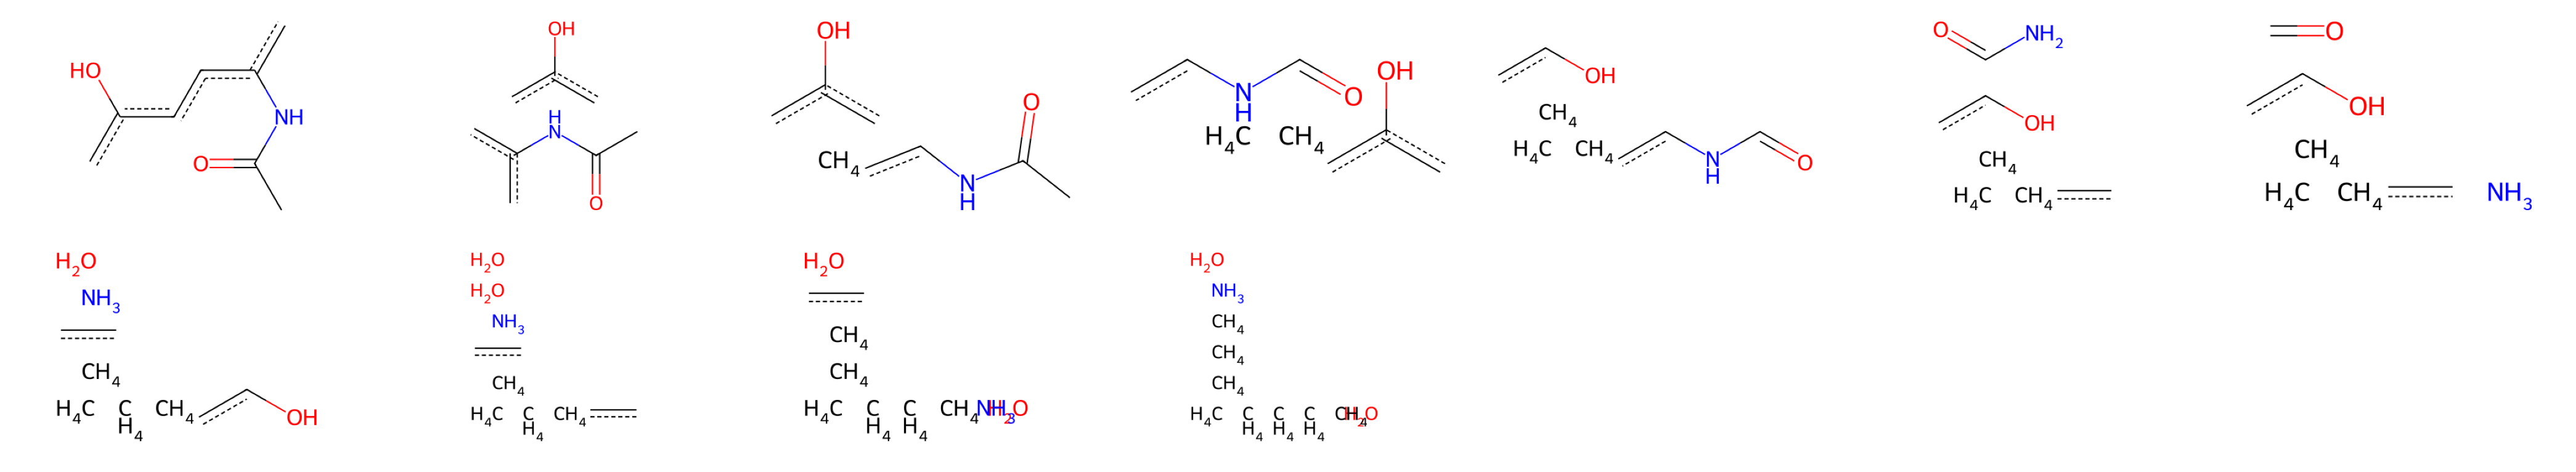

In [8]:
_ = display_graphs(positives[:7*2], n_graphs_per_line=7)

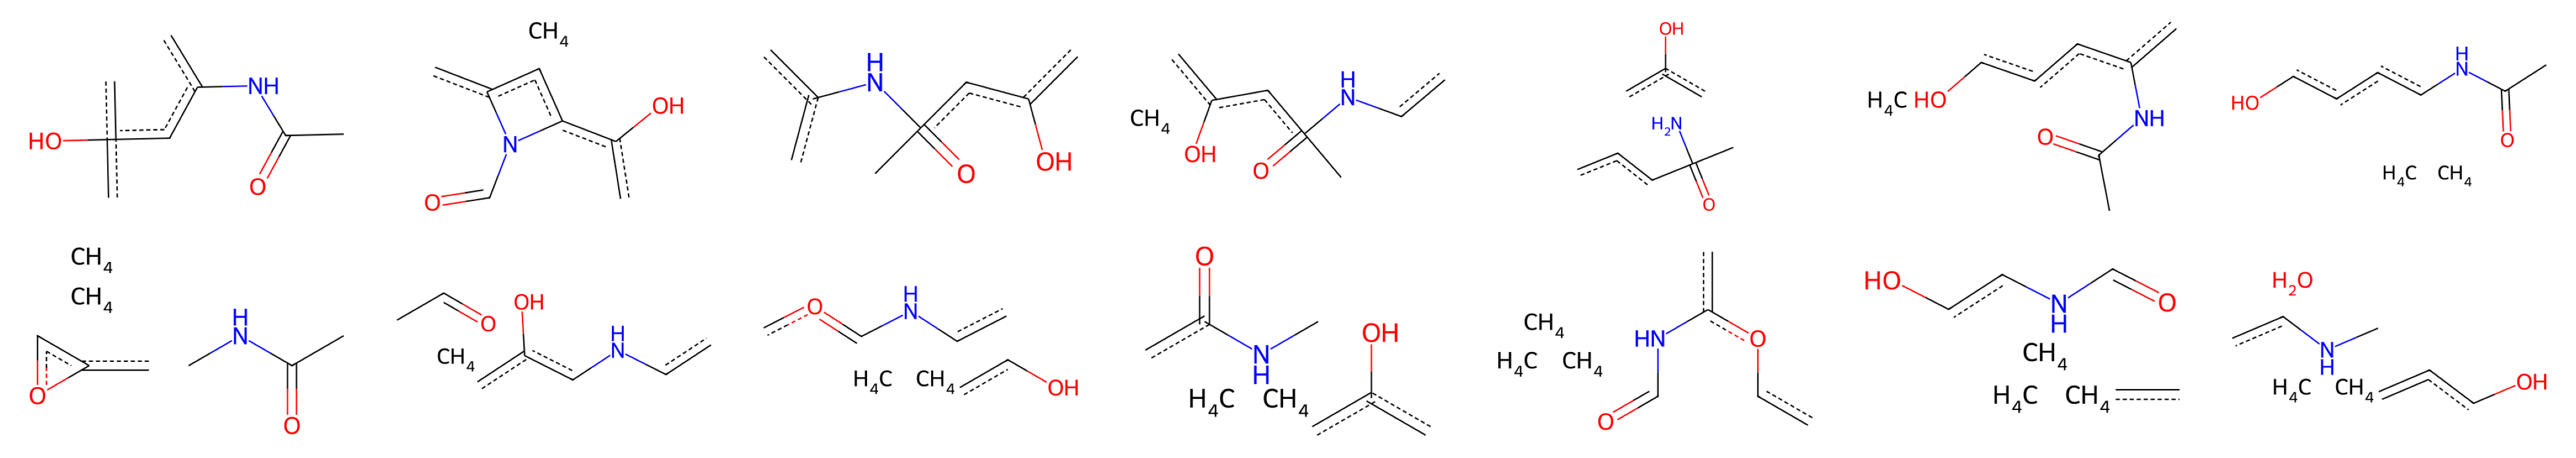

In [9]:
_ = display_graphs(negatives[:7*2], n_graphs_per_line=7)

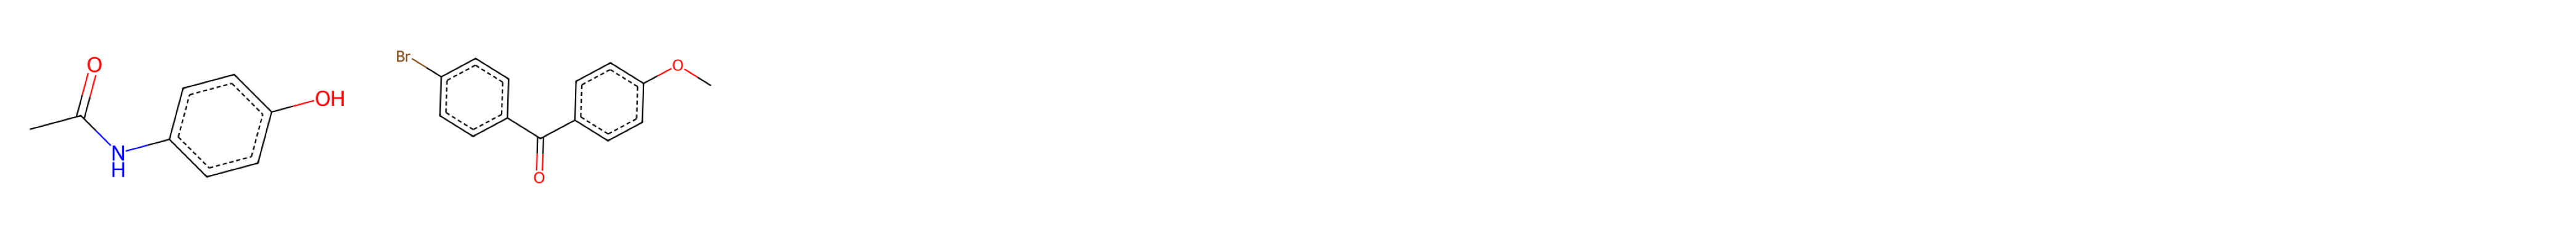

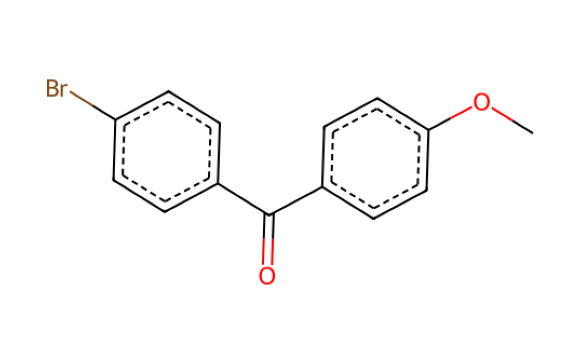

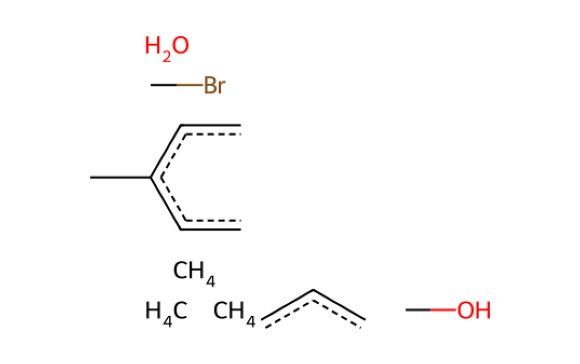

In [ ]:
%%time
fit_graphs = random.sample(graphs, k=min(2, len(graphs)))
_ = display_graphs(fit_graphs, n_graphs_per_line=7)

graph = random.choice(fit_graphs)
_ = display_graphs([graph], n_graphs_per_line=1)

start_graph, target_n_edges = remove_edges(graph, size=.5)
_ = display_graphs([start_graph], n_graphs_per_line=1)

df = neighborhood(radius=(1,2))
transformer = AbstractGraphTransformer(
    nbits=14,
    decomposition_function=df,
    return_dense=True,
    n_jobs=-1,
)
graph_estimator = GraphEstimator(
    transformer=transformer,
    estimator=RandomForestClassifier(random_state=0, n_estimators=300, n_jobs=-1),
)

generator = EdgeGenerator(
    feasibility_estimator,
    graph_estimator,
    n_negative_per_positive=2,
    n_replicates=2,
    beam_size=3,
    fit_n_jobs=-1,
    fit_backend='loky',
    verbose=True,
    seed=0,
).fit(fit_graphs)


path = generator.generate(
    start_graph,
    n_edges=target_n_edges,
    draw_graphs_fn=lambda graphs: display_graphs(graphs, n_graphs_per_line=1),
)

print('n_fit_graphs =', len(fit_graphs))
print('start_n_edges =', start_graph.number_of_edges())
print('target_n_edges =', target_n_edges)
print('path_length =', len(path))
_ = display_graphs(path, n_graphs_per_line=min(len(path), 7))
